# Dynamique sur log-returns

$$\frac{dx_i}{dt} = \mathcal{M}_1(x_i) \sum_j A_{ij}\, \mathcal{M}_2(x_j)$$

- $x_i(t)$ : log-return de l'actif $i$ à l'instant $t$
- $A_{ij}$ : matrice de corrélation nettoyée (RMT + seuil)
- $\mathcal{M}_0 = 0$ car les returns sont zero-mean et $\mathcal{M}_0$ impaire $\Rightarrow \langle \mathcal{M}_0(x) \rangle = 0$

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from functions import load_data, correlation, rmt_clip_correlation, corr_threshold

%matplotlib inline
%config InlineBackend.figure_format='retina'

## 1. Données

146 actions US, log-returns 30 min, 2019–2023.

In [3]:
real  = load_data(['stock'], log_returns=True, sort_by_sector=True)
arr   = real.values
T_, N_ = arr.shape
names = real.columns.tolist()

print(f'Actifs : {N_}   |   Obs : {T_}   |   Période : {real.index[0].date()} → {real.index[-1].date()}')
print(f'Moyenne globale des returns : {arr.mean():.2e}   (≈ 0 => M0 = 0 justifié)')

Actifs : 146   |   Obs : 13360   |   Période : 2019-04-01 → 2023-05-03
Moyenne globale des returns : 3.11e-05   (≈ 0 => M0 = 0 justifié)


## 2. Construction de la matrice $A$

On part de la matrice de corrélation empirique $\hat{C}$ et on la nettoie en deux étapes :

**Étape 1 — RMT clipping (Marchenko-Pastur).**  
Les valeurs propres de $\hat{C}$ inférieures au bord de Marchenko-Pastur
$$\lambda_+ = \sigma^2\left(1 + \sqrt{N/T}\right)^2$$
sont du bruit d'estimation pur. On les remplace par leur moyenne, puis on renormalise à diagonale unité.

**Étape 2 — seuil quantile.**  
On met à zéro les entrées $|C_{ij}|$ inférieures au quantile $q$, ne gardant que les $1-q$ liens les plus forts.

In [4]:
Q = 0.8   # top 20% des liens

C_raw   = correlation(arr, lag=0)
C_clean = rmt_clip_correlation(C_raw, T=T_)
A       = corr_threshold(C_clean, quantile=Q)
np.fill_diagonal(A, 0)

A = C_clean

n_links = (A != 0).sum()
print(f'Liens non nuls : {n_links} / {N_**2}  ({n_links/N_**2*100:.1f}%)')
print(f'Mean |A| sur liens actifs : {np.abs(A[A != 0]).mean():.4f}')

eigvals = np.linalg.eigvalsh(C_raw)
q_mp    = N_ / T_
lp      = (1 + np.sqrt(q_mp))**2
print(f'\nValeurs propres hors bruit MP (> {lp:.2f}) : {(eigvals > lp).sum()} / {N_}')

Liens non nuls : 21316 / 21316  (100.0%)
Mean |A| sur liens actifs : 0.3869

Valeurs propres hors bruit MP (> 1.22) : 12 / 146


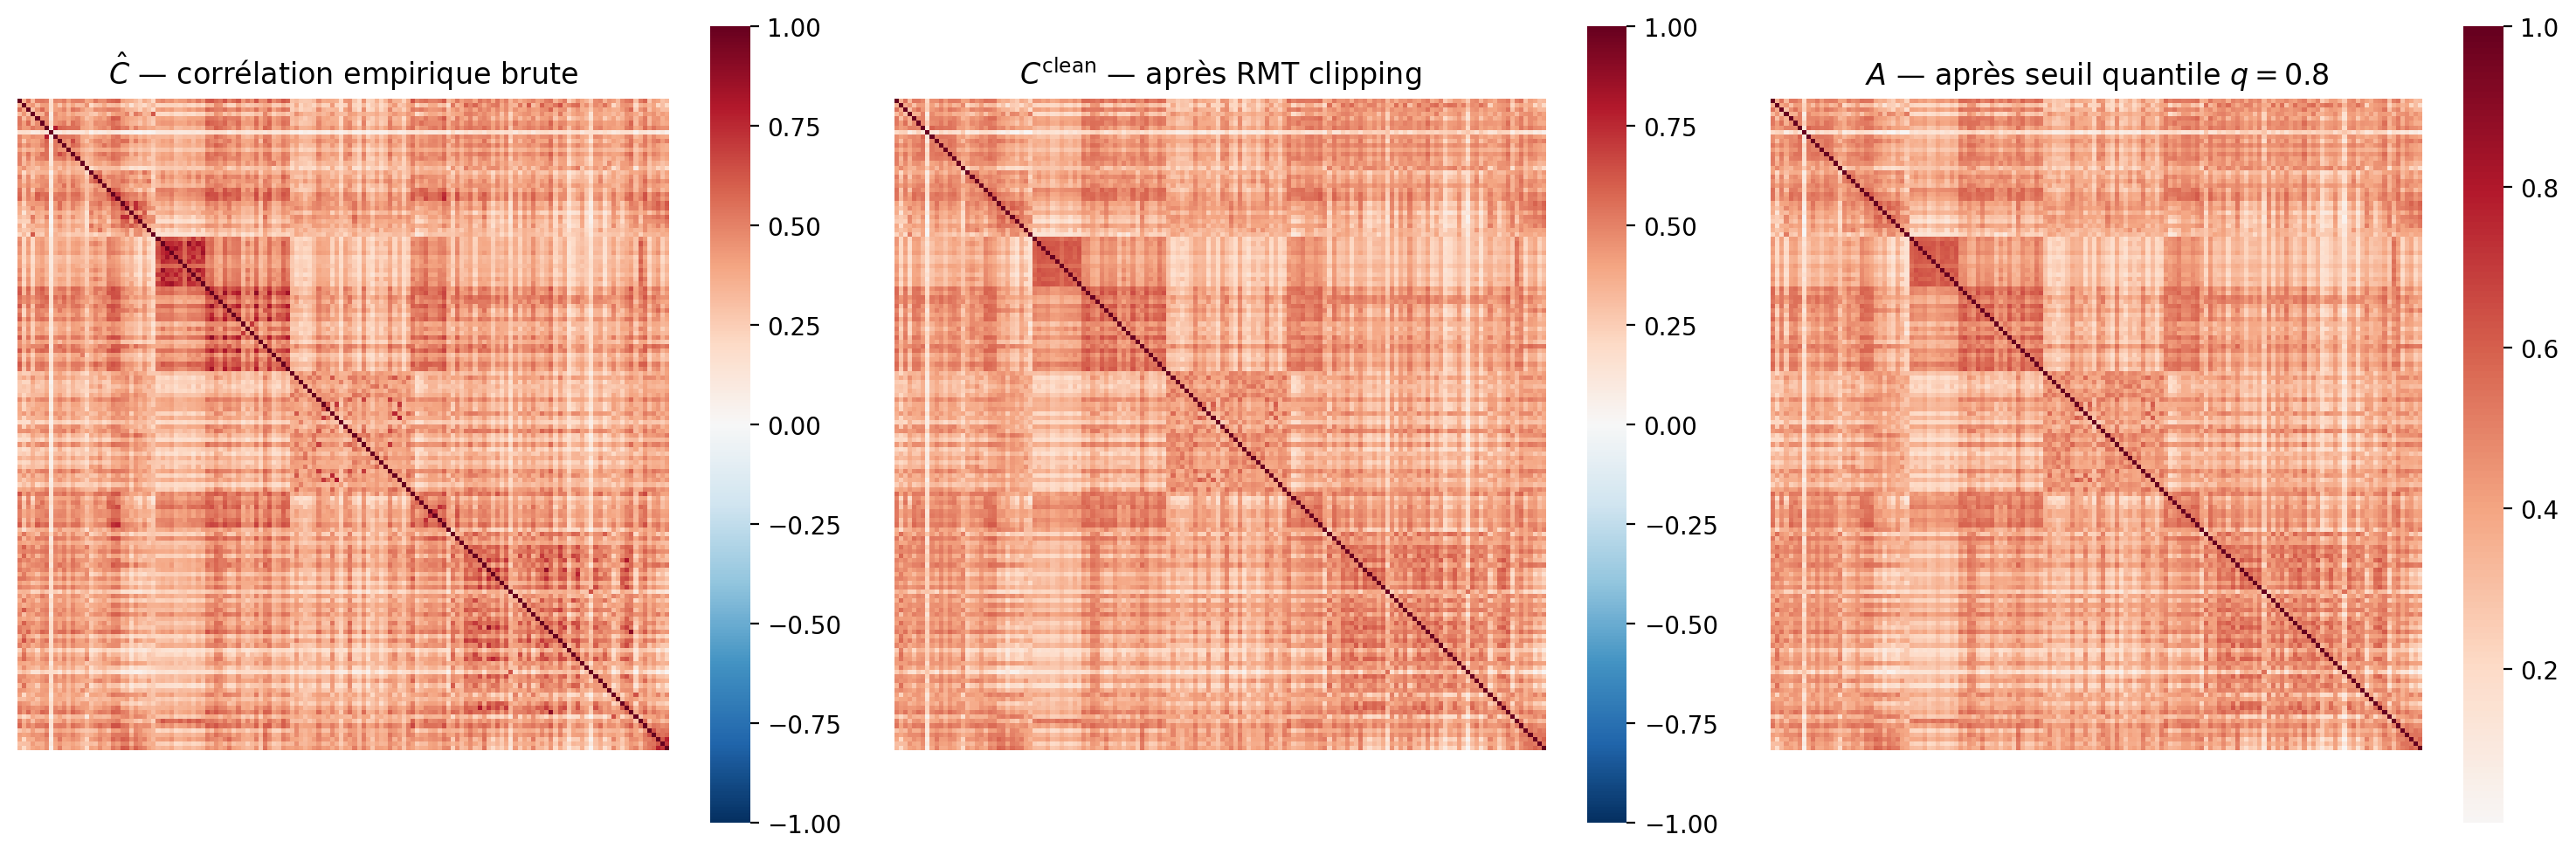

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.heatmap(C_raw, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            ax=axes[0], square=True, xticklabels=False, yticklabels=False)
axes[0].set_title('$\\hat{C}$ — corrélation empirique brute')

sns.heatmap(C_clean, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            ax=axes[1], square=True, xticklabels=False, yticklabels=False)
axes[1].set_title('$C^{\\mathrm{clean}}$ — après RMT clipping')

sns.heatmap(A, cmap='RdBu_r', center=0,
            ax=axes[2], square=True, xticklabels=False, yticklabels=False)
axes[2].set_title(f'$A$ — après seuil quantile $q={Q}$')

plt.tight_layout()
plt.show()

## 3. Modèle discret et fit

En temps discret au lag $L$, l'équation continue devient :

$$x_i(t) = \alpha_i \cdot \mathcal{M}_1\!\left(x_i(t-L)\right) \cdot \underbrace{\sum_j A_{ij}\, \mathcal{M}_2\!\left(x_j(t-L)\right)}_{\text{signal réseau}} + \varepsilon_i(t)$$

On note le prédicteur :

$$P_i(t) = \mathcal{M}_1\!\left(x_i(t-L)\right) \cdot \left[A\, \mathcal{M}_2\!\left(x(t-L)\right)\right]_i$$

et on estime $\alpha_i$ par OLS actif par actif :

$$\hat{\alpha}_i = \arg\min_{\alpha} \sum_t \left(x_i(t) - \alpha \cdot P_i(t)\right)^2$$

In [6]:
LAG = 1

X_lag = arr[:-LAG]
Y     = arr[LAG:]

specs = {
    'M1=1, M2=x'          : (lambda x: np.ones_like(x),  lambda x: x),
    'M1=x, M2=x'          : (lambda x: x,                 lambda x: x),
    'M1=|x|, M2=x'        : (lambda x: np.abs(x),         lambda x: x),
    'M1=1, M2=|x|'        : (lambda x: np.ones_like(x),  lambda x: np.abs(x)),
    'M1=1, M2=sign(x)'    : (lambda x: np.ones_like(x),  lambda x: np.sign(x)),
    'M1=|x|, M2=sign(x)'  : (lambda x: np.abs(x),         lambda x: np.sign(x)),
}

def fit_spec(X_lag, Y, A, f1, f2):
    n      = Y.shape[0]
    P      = f1(X_lag) * (f2(X_lag) @ A)
    alphas = np.empty(N_)
    r2     = np.empty(N_)
    for i in range(N_):
        p, y  = P[:, i], Y[:, i]
        if np.std(p) < 1e-12:
            alphas[i] = r2[i] = 0.
            continue
        Xols  = np.column_stack([np.ones(n), p])
        b, *_ = np.linalg.lstsq(Xols, y, rcond=None)
        alphas[i] = b[1]
        yhat      = Xols @ b
        ss_res    = ((y - yhat)**2).sum()
        ss_tot    = ((y - y.mean())**2).sum()
        r2[i]     = 1 - ss_res / ss_tot if ss_tot > 0 else 0.
    return r2.mean(), alphas, r2

In [7]:
results = {}
print(f'{"spec":<18s}  {"R² IS moy":>10s}  {"R² médian":>10s}  {"alpha médian":>13s}')
print('─' * 60)
for name, (f1, f2) in specs.items():
    r2_mean, alphas, r2_all = fit_spec(X_lag, Y, A, f1, f2)
    results[name] = {'r2_mean': r2_mean, 'alphas': alphas, 'r2_all': r2_all}
    print(f'{name:<18s}  {r2_mean*100:>9.4f}%  {np.median(r2_all)*100:>9.4f}%  {np.median(alphas):>13.5f}')

spec                 R² IS moy   R² médian   alpha médian
────────────────────────────────────────────────────────────
M1=1, M2=x             0.0902%     0.0771%       -0.00069
M1=x, M2=x             0.0906%     0.0358%       -0.01080
M1=|x|, M2=x           0.1479%     0.0792%       -0.01673
M1=1, M2=|x|           0.0429%     0.0197%       -0.00042
M1=1, M2=sign(x)       0.0096%     0.0052%       -0.00000
M1=|x|, M2=sign(x)     0.1320%     0.0870%       -0.00074


## 4. Comparaison : $A$ corrélation vs $A$ VAR (validation)\n\nOn remplace $A$ par la matrice de contagion sparse de validation — subset VAR au lag 13, masque top-10% corrélation. Entrée $(i,j)$ = effet de $x_i(t-13)$ sur $x_j(t)$.\n\nOn relance les mêmes specs avec `LAG=13` pour être cohérent avec la matrice.

In [10]:
from functions import var_contagion_masked

LAG_VAR = 13

var_result = var_contagion_masked(real, lag=LAG_VAR, corr_quantile=0.0, rmt_clip=True)
A_var = var_result.loc[names].values   # (N, N) — A_var[i,j] = effet de i sur j
np.fill_diagonal(A_var, 0)

print(f'Liens non nuls dans A_var : {(A_var != 0).sum()} / {N_**2}  ({(A_var!=0).mean()*100:.1f}%)')
print(f'Mean |A_var| sur liens actifs : {np.abs(A_var[A_var != 0]).mean():.4f}')

Liens non nuls dans A_var : 21169 / 21316  (99.3%)
Mean |A_var| sur liens actifs : 0.0316


In [11]:
X_lag13 = arr[:-LAG_VAR]
Y13     = arr[LAG_VAR:]
n13     = Y13.shape[0]

print(f'{"spec":<22s}  {"A=corr R² moy":>14s}  {"A=VAR R² moy":>13s}')
print('─' * 55)
for name, (f1, f2) in specs.items():
    r2_corr, *_ = fit_spec(X_lag13, Y13, A,     f1, f2)
    r2_var,  *_ = fit_spec(X_lag13, Y13, A_var, f1, f2)
    print(f'{name:<22s}  {r2_corr*100:>13.4f}%  {r2_var*100:>12.4f}%')

spec                     A=corr R² moy   A=VAR R² moy
───────────────────────────────────────────────────────
M1=1, M2=x                     0.0986%        7.2982%
M1=x, M2=x                     0.1570%        0.5179%
M1=|x|, M2=x                   0.3210%        7.3583%
M1=1, M2=|x|                   0.0503%        0.1320%
M1=1, M2=sign(x)               0.0035%        0.1927%
M1=|x|, M2=sign(x)             0.1077%        1.5684%
